In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from sklearn import metrics

https://stackoverflow.com/questions/79674833/scipy-optimizewarning-covariance-of-the-parameters-could-not-be-estimated-when

In [2]:
kb = 1.380649e-23
#kb = 8.617333262e-5
B = 0.3808

def model(J, T, N):
    return N * (B * (2 * J + 1) / (kb * T) * np.exp(- B * J * (J + 1)/ (kb * T)))


In [3]:
J = np.array([2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48])
N = np.array([0.185,0.375,0.548,0.695,0.849,0.931,0.996,0.992,1.0,0.977,0.927,0.834,0.691,0.68,0.575,0.479,0.421,0.351,0.259,0.208,0.162,0.135,0.093,0.066])

In [4]:
popt, pcov = optimize.curve_fit(model, J, N, p0=[1e25, 1])
popt, pcov

(array([1.57074788e+25, 2.75770708e+01]),
 array([[4.57803036e+46, 2.03186961e+22],
        [2.03186961e+22, 6.04461029e-02]]))

In [5]:
Nhat = model(J, *popt)
metrics.r2_score(N, Nhat)

0.9940231921240703

In [6]:
Jlin = np.linspace(J.min(), J.max(), 200)
Nlin = model(Jlin, *popt)
Nlin

array([0.23957956, 0.2611765 , 0.28262771, 0.30392145, 0.32504616,
       0.34599041, 0.36674295, 0.3872927 , 0.40762877, 0.42774046,
       0.44761729, 0.46724899, 0.48662549, 0.50573699, 0.52457391,
       0.54312691, 0.56138693, 0.57934516, 0.59699305, 0.61432234,
       0.63132506, 0.64799351, 0.66432029, 0.68029831, 0.69592077,
       0.7111812 , 0.72607341, 0.74059157, 0.75473012, 0.76848388,
       0.78184793, 0.79481774, 0.80738908, 0.81955804, 0.83132106,
       0.84267491, 0.85361668, 0.86414383, 0.8742541 , 0.88394559,
       0.89321674, 0.90206629, 0.91049334, 0.91849729, 0.92607786,
       0.9332351 , 0.93996939, 0.94628138, 0.95217207, 0.95764275,
       0.962695  , 0.96733069, 0.97155201, 0.97536141, 0.97876161,
       0.98175563, 0.98434674, 0.98653847, 0.98833461, 0.9897392 ,
       0.9907565 , 0.99139102, 0.9916475 , 0.9915309 , 0.99104636,
       0.99019927, 0.98899517, 0.98743982, 0.98553915, 0.98329925,
       0.9807264 , 0.977827  , 0.97460762, 0.97107497, 0.96723

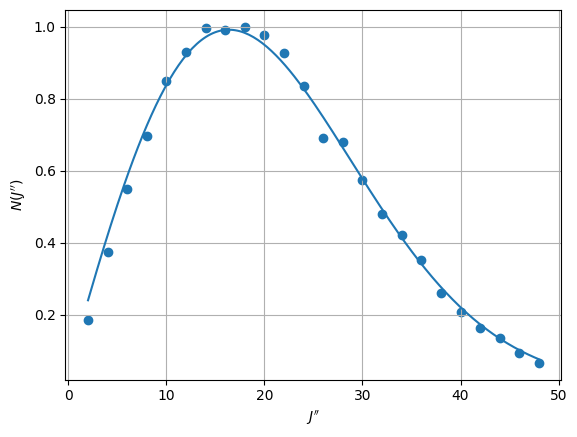

In [7]:
fig, axe = plt.subplots()
axe.scatter(J, N)
axe.plot(Jlin, Nlin)
axe.set_xlabel("$J''$")
axe.set_ylabel("$N(J'')$")
axe.grid()